# KNN Regression on Insurance Dataset
Complete notebook with EDA, preprocessing, correlation analysis, training, tuning, evaluation, and model saving.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Load Dataset

In [2]:
df = pd.read_csv('../data/insurance.csv')
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Dataset Overview

In [3]:
print("Shape:", df.shape)
df.info()


Shape: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Missing Values and Duplicates

In [5]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


Missing Values
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate Rows: 1


## Numerical Feature Distributions

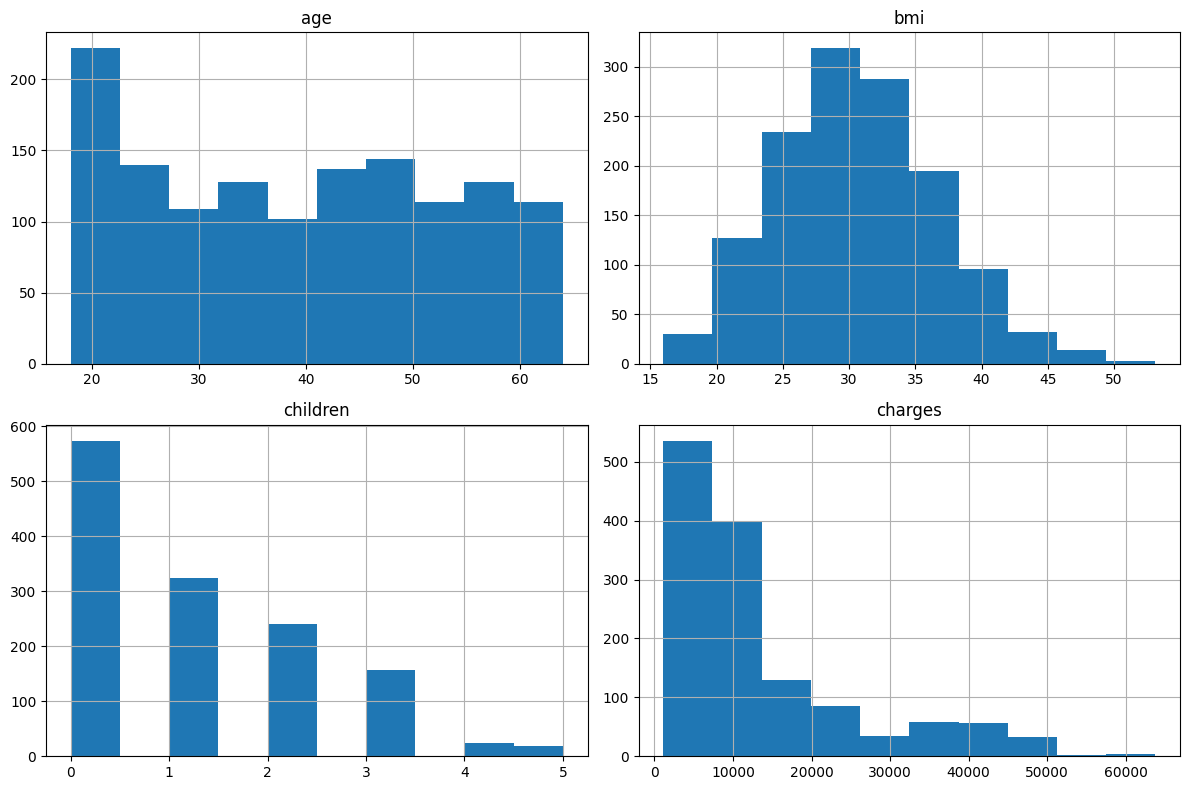

In [6]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()


## Target Variable Distribution

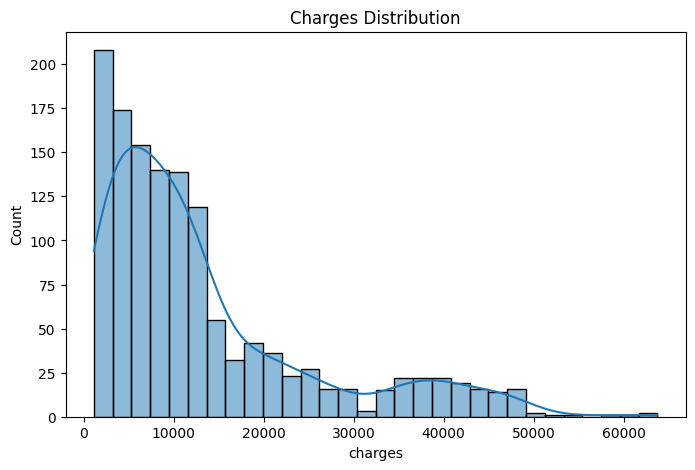

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True)
plt.title('Charges Distribution')
plt.show()


## Boxplots for Outlier Detection

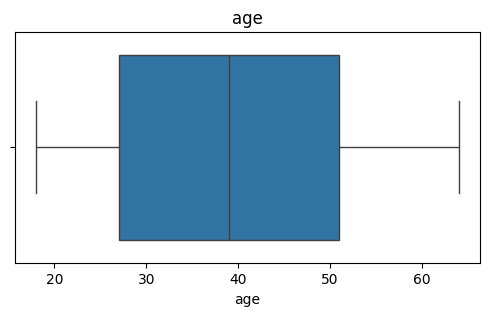

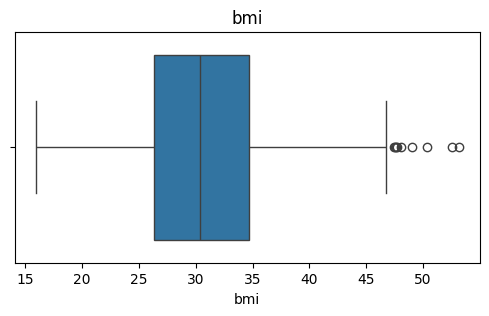

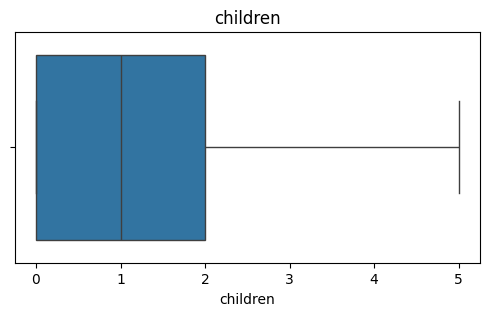

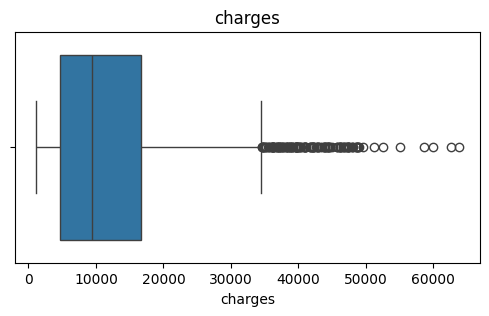

In [8]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


## Categorical Feature Analysis

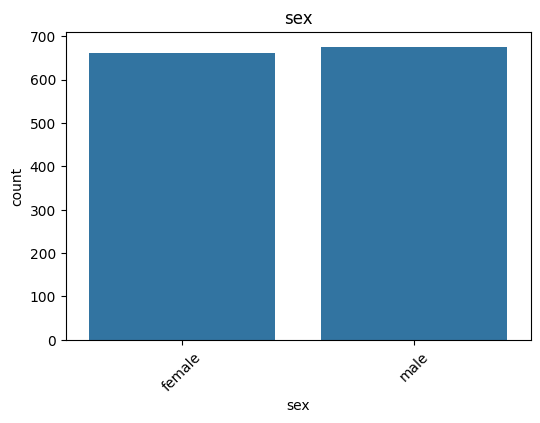

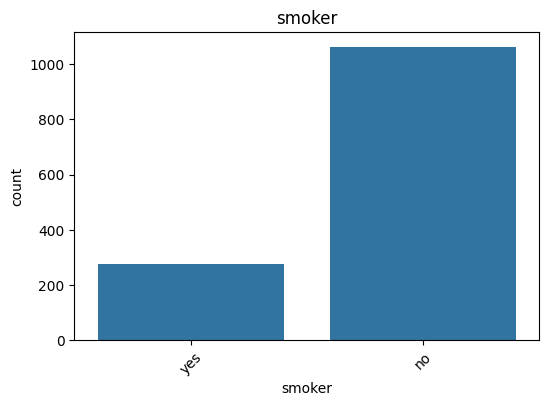

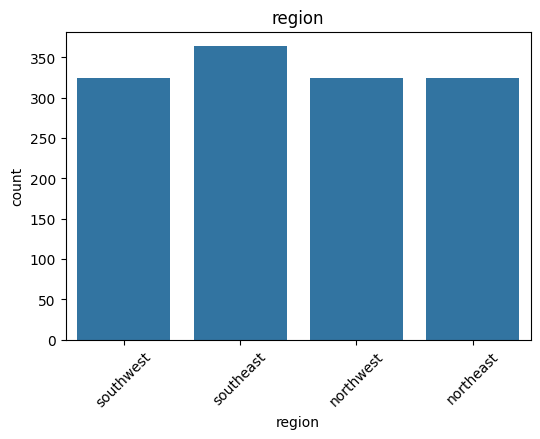

In [9]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()


## Encoding Categorical Features

In [10]:
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    encoder = LabelEncoder()
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

df_encoded.head()


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


## Correlation Analysis

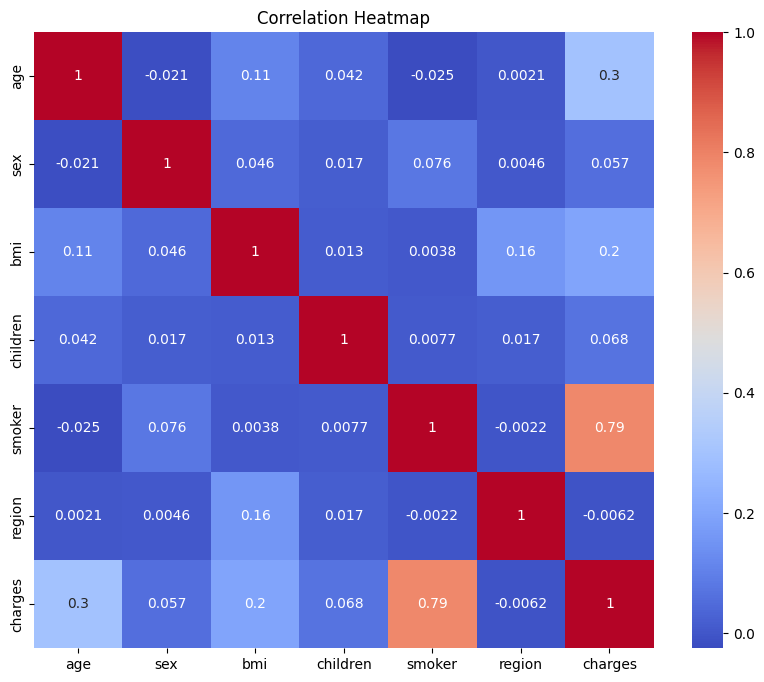

In [11]:
corr = df_encoded.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [12]:
corr['charges'].sort_values(ascending=False)


charges     1.000000
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
sex         0.057292
region     -0.006208
Name: charges, dtype: float64

## Feature and Target Split

In [13]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']


## Feature Scaling (Important for KNN)

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Train Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)


(1070, 6) (268, 6)


## Train KNN Regressor

In [16]:
model = KNeighborsRegressor(n_neighbors=5)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


## Model Evaluation

In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE : 3044.069795675373
MSE : 25775853.306418702
RMSE: 5076.992545436589
R2 Score: 0.8339706027950087


## Hyperparameter Tuning

In [18]:
params = {
    'n_neighbors': list(range(1,21))
}

grid = GridSearchCV(
    KNeighborsRegressor(),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Parameters: {'n_neighbors': 9}
Best Score: 0.7995752896406808


## Actual vs Predicted

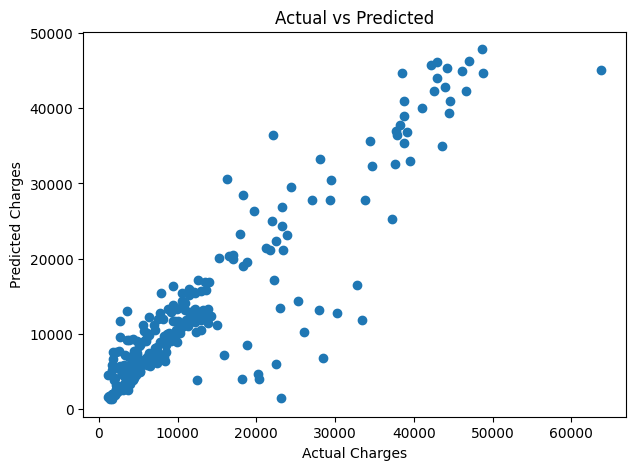

In [19]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()


## Save Model and Scaler

In [20]:
pickle.dump(
    model,
    open('../models/knn_model.pkl', 'wb')
)

pickle.dump(
    scaler,
    open('../models/scaler.pkl', 'wb')
)

print("Model and Scaler Saved Successfully")


Model and Scaler Saved Successfully
